In [1]:
import os
import shutil
import random
import tqdm
import torch
import torchaudio
import torchaudio.functional as ff
import torchaudio.transforms as tt
import matplotlib.pyplot as plt

In [2]:
ROOT_SRC = '/home/ovistetom/Documents/Databases_Local/VCTK/original/wav48_silence_trimmed'
ROOT_DST = '/home/ovistetom/Documents/Databases_Local/VCTK/preprocessed'
SAMPLE_RATE = 16000
os.makedirs(ROOT_DST, exist_ok=True)

## Pre-Process Dataset

In [3]:
list_speakers = os.listdir(ROOT_SRC)
num_speakers = len(list_speakers)
random.shuffle(list_speakers)
print(list_speakers[:10])

['p317', 'p335', 'p314', 'p285', 'p231', 'p228', 'p334', 'p336', 'p246', 'p313']


In [4]:
tst_size = int(0.1*num_speakers)
val_size = int(0.1*num_speakers)
trn_size = num_speakers - val_size - tst_size
list_trn = list_speakers[:trn_size]
list_val = list_speakers[trn_size:trn_size+val_size]
list_tst = list_speakers[trn_size+val_size:]
print(len(list_trn), len(list_val), len(list_tst))

89 11 11


In [5]:
RESAMPLER = tt.Resample(orig_freq=48000, new_freq=SAMPLE_RATE)
FADER = tt.Fade(fade_in_len=64, fade_out_len=64)

In [6]:
for name_subset, list_subset in zip(['trn', 'val', 'tst'], [list_trn, list_val, list_tst]):
    break
    path_subset_dst = os.path.join(ROOT_DST, name_subset)
    os.makedirs(path_subset_dst, exist_ok=True)

    for name_speaker in tqdm.tqdm(list_subset):

        path_speaker_src = os.path.join(ROOT_SRC, name_speaker)
        if not os.path.isdir(path_speaker_src):
            continue

        for i_sample, name_sample in enumerate(os.listdir(path_speaker_src)):

            path_sample_src = os.path.join(path_speaker_src, name_sample)
            path_sample_dst = os.path.join(path_subset_dst, f"{name_speaker}_{i_sample:04d}.flac")
            waveform, sr = torchaudio.load(uri=path_sample_src, normalize=True, channels_first=True)

            if waveform.size(0) > 1:
                waveform = waveform[0].unsqueeze(0)

            if waveform.mean() > 0.1:
                waveform = waveform - waveform.mean()

            if sr != SAMPLE_RATE:
                assert sr == 48000, f"Sample rate {sr} not supported."
                waveform = RESAMPLER(waveform)
            
            waveform = FADER(waveform)
            waveform = waveform / waveform.abs().max()

            torchaudio.save(uri=path_sample_dst, src=waveform, sample_rate=SAMPLE_RATE, channels_first=True)


___

## Analyse Dataset

In [30]:
ROOT_DB = os.path.join(ROOT_DST, 'trn')

list_waveform_length = []
list_waveform_power = []
for sample_name in os.listdir(ROOT_DB):
    sample_path = os.path.join(ROOT_DB, sample_name)
    waveform, sr = torchaudio.load(uri=sample_path, normalize=True, channels_first=True)
    list_waveform_length.append(waveform.size(1) / sr)
    list_waveform_power.append((waveform.pow(2).sum() / waveform.size(1)).log().item())

print(f"Num. samples: {len(list_waveform_length)}")

Num. samples: 70750


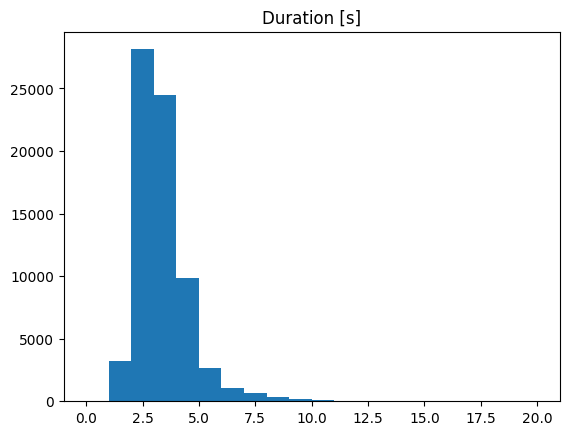

In [31]:
fig, axs = plt.subplots(1,1)
axs.hist(list_waveform_length, bins=20, range=(0, 20))
axs.set_title('Duration [s]')
plt.show()

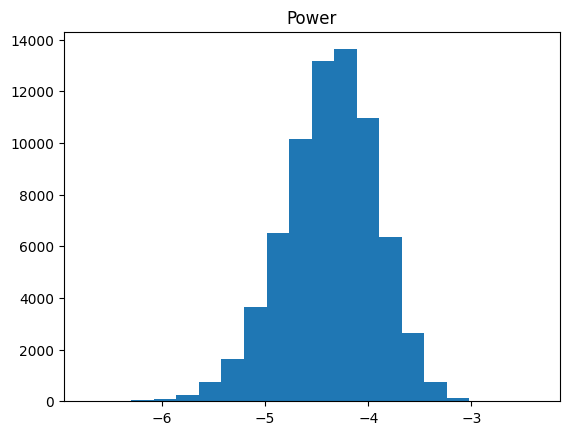

In [32]:
fig, axs = plt.subplots(1,1)
axs.hist(list_waveform_power, bins=20)
axs.set_title('Power')
plt.show()